In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
X,y = make_classification(n_samples=200 , n_features=2 , n_redundant=0 , random_state=30)

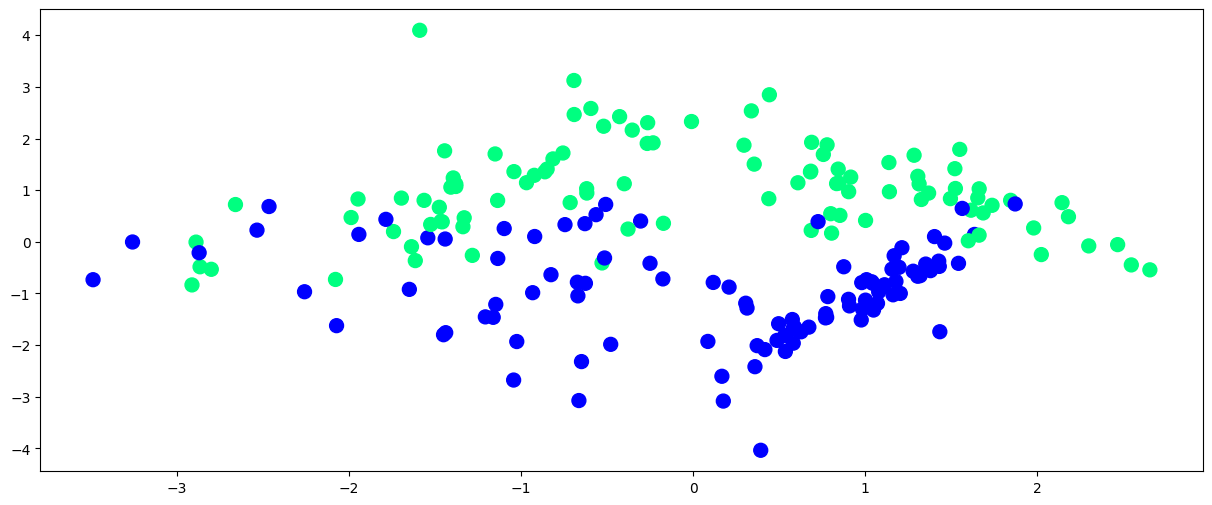

In [3]:
plt.figure(figsize=(15,6))
plt.scatter(X[:,0] ,X[:,1],c=y , cmap='winter',s=100)

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=30)

In [5]:
m=X_train.shape[0]
n=X_train.shape[1]

In [6]:
from sklearn.linear_model import LogisticRegression

In [7]:
lor= LogisticRegression()

In [8]:
lor.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [9]:
y_pred = lor.predict(X_test)

In [10]:
print(lor.coef_)
print(lor.intercept_)

[[0.04600485 2.27982918]]
[-0.13905277]


In [11]:
def sigmoid(z):
    z = np.clip(z, -500, 500) 
    return 1/(1 + np.exp(-z))

In [12]:
print(sigmoid(0))
print(sigmoid(100))
print(sigmoid(-100))

0.5
1.0
3.7200759760208356e-44


In [13]:

weights = np.zeros(n)
bias = 0
learning_rate = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    z = np.dot(X_train, weights) + bias
    y_pred = sigmoid(z)
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    
    dw = (1/m) * np.dot(X_train.T, (y_pred - y_train))
    db = (1/m) * np.sum(y_pred - y_train)
    
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db
    
    loss = -(1/m) * np.sum(y_train * np.log(y_pred) + 
                           (1 - y_train) * np.log(1 - y_pred))
    loss_history.append(loss)

print(f"Final weights: {weights}")
print(f"Final bias: {bias}")

Final weights: [0.01023188 1.5841426 ]
Final bias: -0.042351518303163756


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
weights = np.zeros(n)
bias = 0
learning_rate = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    z = np.dot(X_train_scaled, weights) + bias
    y_pred = sigmoid(z)
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    
    dw = (1/m) * np.dot(X_train_scaled.T, (y_pred - y_train))
    db = (1/m) * np.sum(y_pred - y_train)
    
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db
    
    loss = -(1/m) * np.sum(y_train * np.log(y_pred) + 
                           (1 - y_train) * np.log(1 - y_pred))
    loss_history.append(loss)

print(f"Final weights: {weights}")
print(f"Final bias: {bias}")

Final weights: [-0.00358634  1.62202507]
Final bias: -0.051578462679385886


In [17]:
print("Your weights:", weights)
print("Sklearn weights:", lor.coef_)

print("Your bias:", bias)
print("Sklearn bias:", lor.intercept_)

Your weights: [-0.00358634  1.62202507]
Sklearn weights: [[0.04600485 2.27982918]]
Your bias: -0.051578462679385886
Sklearn bias: [-0.13905277]


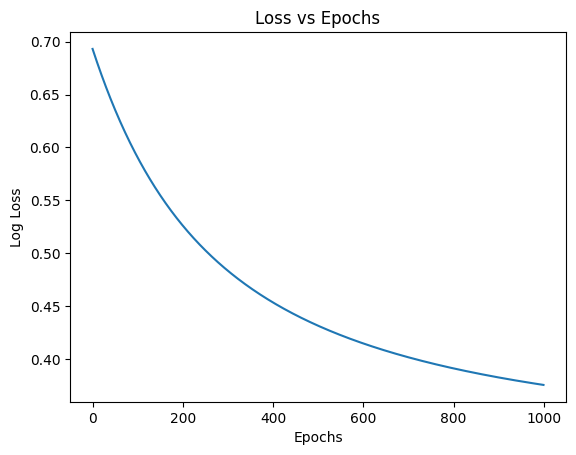

In [18]:
plt.plot(loss_history)
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_final = sigmoid(np.dot(X_test_scaled, weights) + bias)
y_pred_classes = (y_pred_final >= 0.5).astype(int)

print("Your accuracy:", accuracy_score(y_test, y_pred_classes))
print("Sklearn accuracy:", accuracy_score(y_test, lor.predict(X_test)))

Your accuracy: 0.9
Sklearn accuracy: 0.9


## Logistic Regression From Scratch

Implemented Logistic Regression using gradient descent without sklearn.

Key concepts used:
- Sigmoid function to convert outputs to probabilities
- Log loss instead of MSE
- Gradient descent to update weights and bias
- Feature scaling to prevent gradient explosion

Results:
- Custom implementation accuracy: 90%
- Sklearn accuracy: 90%